In [1]:
import matplotlib
# matplotlib.use('nbagg')
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 15
import pandas as pd
import numpy as np
# %matplotlib nbagg

In [2]:
physbo_dir = "physbo_data/"
nts_dir = "NTS_data/"

In [3]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
mathods2marker = {"BBO_TS": ".", "NTS": "x"}
methods = ["Random", "BBO_TS", "DPP_TS", "NTS", "NTS_DPP"]
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
method2color = {}
for i in range(len(methods)):
    method2color[methods[i]] = colors[i]
method2style = {
    "Random": "-",
    "BBO_TS": "--",
    "DPP_TS": "-.",
    "NTS": ":",
    "NTS_DPP": "-",
}
method2color = {}
for i in range(len(methods)):
    method2color[methods[i]] = colors[i]
method2color = {
    "aggressive": "red",
    "moderate": "blue",
    "NTS": "green",
    "BBO_TS": "orange",
}
methods = ["BBO_TS", "NTS"]

# 最大値

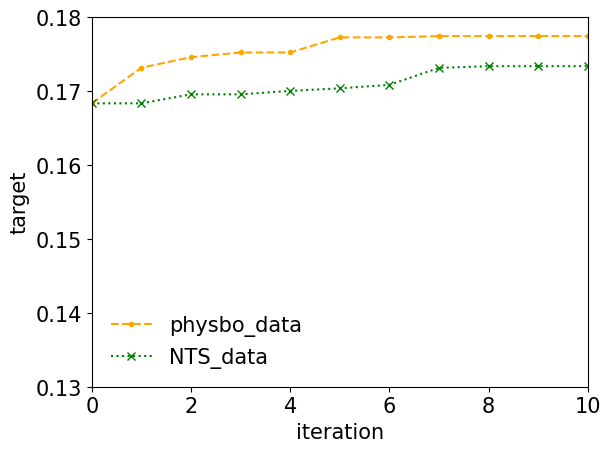

In [4]:
import pathlib

fig, ax = plt.subplots()
features_list = []
for i, dir_path in enumerate([physbo_dir, nts_dir]):
    # dir_path 以下にあるファイル一覧を pathlib を使って取得
    path = pathlib.Path(dir_path)
    file_list = list(path.glob("*"))
    # タイトルを日付順にソートし、for 文で処理
    file_list.sort()
    target_list = [-np.inf]
    features = []
    all_target = []
    th_history = []
    for file in file_list:
        # 各csvファイルを読み込み、1列目をaction_id, 2~最終行までをfeature_1~feature_N, 最終行をtargetとして読み込む
        df = pd.read_csv(file, header=None)
        action_id = df[0]
        feature = df.iloc[:, 1:-1]
        features.append(feature)
        target = df.iloc[:, -1]
        all_target.extend([e for e in target if pd.notnull(e)])
        th = np.percentile(np.array(all_target), 90)
        # print(th, all_target)
        th_history.append(max(th, max(th_history, default=0)))
        target_list.append(max([np.max(target_list), max(target)]))
    target_list = np.array(target_list)
    ax.plot(list(range(len(target_list[1:]))), target_list[1:], label=dir_path.strip("/"), color=method2color[methods[i]], marker=mathods2marker[methods[i]], linestyle=method2style[methods[i]])
    # if i == 1:
    #     ax.plot(list(range(len(th_history))), th_history, label="Threshold (conservative mode)", color="black", linestyle="--")
    features_list.append(features)
ax.legend(frameon=False, fontsize=15)
ax.set_ylabel("target", fontsize=15)
ax.set_xlabel("iteration", fontsize=15)
ax.set_xlim(0, 10)
ax.set_ylim(0.13, 0.18)
plt.savefig("nts_physbo_comparison_max.pdf", bbox_inches='tight')

In [ ]:
import pathlib

features_list = []
fig, ax = plt.subplots()
for i, dir_path in enumerate([physbo_dir, nts_dir]):
    # dir_path 以下にあるファイル一覧を pathlib を使って取得
    path = pathlib.Path(dir_path)
    file_list = list(path.glob("*"))
    # タイトルを日付順にソートし、for 文で処理
    file_list.sort()
    target_list = [-np.inf]
    features = []
    all_target = []
    th_history = []
    for j, file in enumerate(file_list):
        # 各csvファイルを読み込み、1列目をaction_id, 2~最終行までをfeature_1~feature_N, 最終行をtargetとして読み込む
        df = pd.read_csv(file, header=None)
        action_id = df[0]
        feature = df.iloc[:, 1:-1]
        features.append(feature)
        target = df.iloc[:, -1]
        all_target.extend([e for e in target if pd.notnull(e)])
        th = np.percentile(np.array(all_target), 90)
        # print(th, all_target)
        th_history.append(max(th, max(th_history, default=0)))
        target_list.append(max([np.max(target_list), max(target)]))
        ax.scatter([j+i*0.2 for _ in range(len(target))], target, color=method2color[methods[i]], marker=mathods2marker[methods[i]], alpha=0.3, s=15)
    target_list = np.array(target_list)
    ax.plot(list(range(len(target_list[1:]))), target_list[1:], label=dir_path.strip("/"), color=method2color[methods[i]], marker=mathods2marker[methods[i]], linestyle=method2style[methods[i]])
    # if i == 1:
    #     ax.plot(list(range(len(th_history))), th_history, label="Threshold (conservative mode)", color="black", linestyle="--")
    features_list.append(features)
    # ax.legend(frameon=False, fontsize=15)
ax.set_ylabel("target", fontsize=15)
ax.set_xlabel("iteration", fontsize=15)
ax.set_xlim(0, 10)
ax.set_ylim(0, 0.19)
plt.savefig("nts_physbo_comparison_max_with_scatter.pdf", bbox_inches='tight')

[0.10009556 0.13618    0.10789111 0.12054931 0.16202111 0.10772653
 0.16361236 0.10762139 0.10848972 0.07203306 0.10832264 0.11815806
 0.11087681 0.10522861 0.11256167 0.11209028 0.11062986 0.12043792
 0.10783583 0.09958889 0.10159944 0.10521194 0.10617583 0.13460667
 0.10336292 0.10642778 0.0934825  0.11265111 0.15965056 0.05511611
 0.11216556 0.09979194 0.11255764 0.11723278 0.11827181 0.1105725
 0.11328111 0.1045075  0.11244431 0.11374014 0.11239958 0.16833681
 0.10186056 0.14215694 0.10951056 0.10608194 0.11698722 0.09856444]
[0.11180417 0.171565   0.10344917 0.10815889 0.16042069 0.17282722
 0.17146292 0.11671417 0.16742083 0.16399917 0.1240375  0.12699736
 0.16000028 0.16501417 0.16376069 0.16334597 0.10248667 0.09816569
 0.10323361 0.16020139 0.11868153 0.15751236 0.12318208 0.10578847
 0.10374417 0.15689514 0.14923597 0.16722528 0.101505   0.11057583
 0.12594972 0.15662944 0.15432806 0.17174125 0.16265847 0.16780569
 0.16322417 0.11085889 0.16662667 0.09644278 0.16434944 0.1731

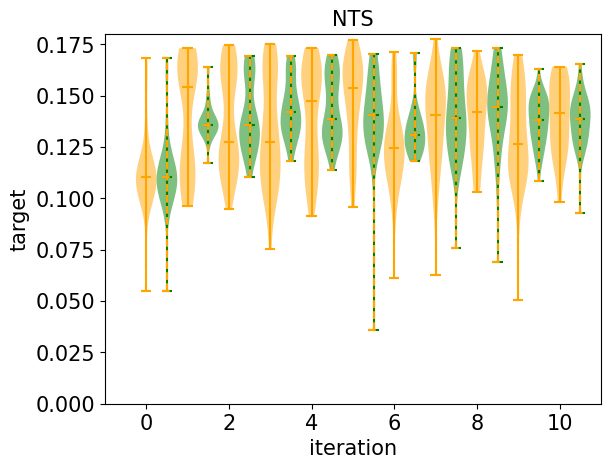

In [ ]:
import pathlib
from matplotlib.collections import LineCollection

features_list = []
fig, ax = plt.subplots()
for i, dir_path in enumerate([physbo_dir, nts_dir]):
    # dir_path 以下にあるファイル一覧を pathlib を使って取得
    path = pathlib.Path(dir_path)
    file_list = list(path.glob("*"))
    # タイトルを日付順にソートし、for 文で処理
    file_list.sort()
    target_list = [-np.inf]
    features = []
    all_target = []
    th_history = []
    for j, file in enumerate(file_list):
        # 各csvファイルを読み込み、1列目をaction_id, 2~最終行までをfeature_1~feature_N, 最終行をtargetとして読み込む
        df = pd.read_csv(file, header=None)
        action_id = df[0]
        feature = df.iloc[:, 1:-1]
        features.append(feature)
        target = df.iloc[:, -1]
        trg = target.to_numpy()
        # Remove zeros from trg
        trg = trg[trg > 0.01]
        print(trg)
        # Violin plot from `trg`
        # Set the color of the violin plot based on the method
        violin_parts = ax.violinplot(trg, positions=[j+0.5*i], widths=0.5, showmeans=False, showmedians=True)
        colors = [method2color[k] for k in methods]
        lines = [method2style[k] for k in methods]
        for pc in violin_parts['bodies']:
            pc.set_facecolor(method2color[methods[i]])
            pc.set_alpha(0.5)
        for v in ['cmedians', 'cbars', 'cmins', 'cmaxes']:
            violin_parts[v].set_colors(method2color[methods[i]])
            segments = violin_parts[v].get_segments()
            for segment, color, linestyle in zip(segments, colors, lines):
                line = LineCollection([segment], colors=[color], linestyles=[linestyle])
                ax.add_collection(line)  # 個別の線として
        # Set median line color to match the method color
        # violin_parts['cmedians'].set_colors(method2color[methods[i]])
        # Set the color of other violin plot components to match the method color
        # violin_parts['cmaxes'].set_colors(method2color[methods[i]])
        # violin_parts['cmins'].set_colors(method2color[methods[i]])
        # violin_parts['cbars'].set_colors(method2color[methods[i]])
        
        # all_target.extend([e for e in target if pd.notnull(e)])
        # th = np.percentile(np.array(all_target), 90)
        # # print(th, all_target)
        # th_history.append(max(th, max(th_history, default=0)))
        # target_list.append(max([np.max(target_list), max(target)]))
        # ax.scatter([j+i*0.2 for _ in range(len(target))], target, color=method2color[methods[i]], marker=mathods2marker[methods[i]], alpha=0.3, s=15)
    # target_list = np.array(target_list)
    # ax.plot(list(range(len(target_list[1:]))), target_list[1:], label=dir_path.strip("/"), color=method2color[methods[i]], marker=mathods2marker[methods[i]], linestyle=method2style[methods[i]])
    # if i == 1:
    #     ax.plot(list(range(len(th_history))), th_history, label="Threshold (conservative mode)", color="black", linestyle="--")
    # features_list.append(features)
    # ax.legend(frameon=False, fontsize=15)
    ax.set_ylabel("target", fontsize=15)
    ax.set_xlabel("iteration", fontsize=15)
    ax.set_xlim(-1, 11)
    if i == 0:
        ax.set_title("PHYSBO", fontsize=15)
    else:
        ax.set_title("NTS", fontsize=15)
    ax.set_ylim(0, 0.18)
# plt.savefig("nts_physbo_comparison_max_with_scatter.pdf", bbox_inches='tight')

Text(0.5, 0, 'NTS data')

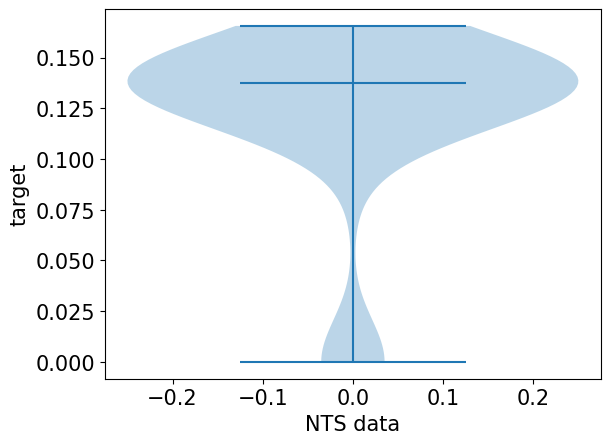

In [ ]:
trg = target.to_numpy()
# violinplot from `trg`
fig, ax = plt.subplots()
ax.violinplot(trg[~np.isnan(trg)], positions=[0], widths=0.5, showmeans=False, showmedians=True)
ax.set_ylabel("target", fontsize=15)
ax.set_xlabel("NTS data", fontsize=15)

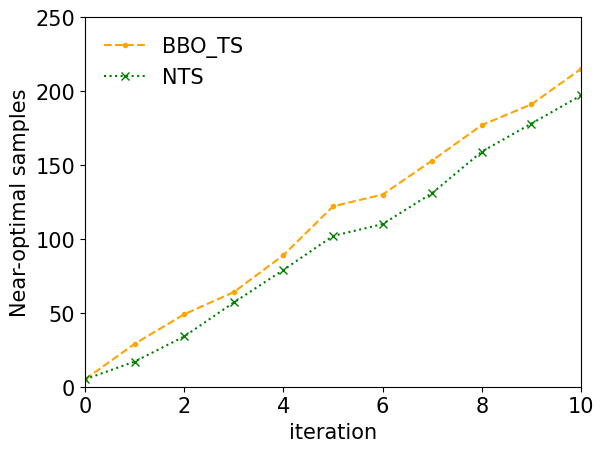

In [ ]:
# The number of near-optimal samples
th = 0.14

from collections import defaultdict

near_optimal_samples_num = defaultdict(list)

fig, ax = plt.subplots()
for i, dir_path in enumerate([physbo_dir, nts_dir]):
    # dir_path 以下にあるファイル一覧を pathlib を使って取得
    path = pathlib.Path(dir_path)
    file_list = list(path.glob("*"))
    # タイトルを日付順にソートし、for 文で処理
    file_list.sort()
    th_history = []
    for file in file_list:
        # 各csvファイルを読み込み、1列目をaction_id, 2~最終行までをfeature_1~feature_N, 最終行をtargetとして読み込む
        df = pd.read_csv(file, header=None)
        action_id = df[0]
        feature = df.iloc[:, 1:-1]
        features.append(feature)
        target = df.iloc[:, -1]
        # Count the number of elements above the threshold
        if len(near_optimal_samples_num[methods[i]]) == 0:
            near_optimal_samples_num[methods[i]].append(np.sum(target >= th))
        else:
            near_optimal_samples_num[methods[i]].append(near_optimal_samples_num[methods[i]][-1]+np.sum(target >= th))
ax.plot(list(range(len(near_optimal_samples_num[methods[0]]))), near_optimal_samples_num[methods[0]], label=methods[0], color=method2color[methods[0]], marker=mathods2marker[methods[0]], linestyle=method2style[methods[0]])
ax.plot(list(range(len(near_optimal_samples_num[methods[1]]))), near_optimal_samples_num[methods[1]], label=methods[1], color=method2color[methods[1]], marker=mathods2marker[methods[1]], linestyle=method2style[methods[1]])

ax.legend(frameon=False, fontsize=15)
ax.set_ylabel("Near-optimal samples", fontsize=15)
ax.set_xlabel("iteration", fontsize=15)
ax.set_xlim(0, 10)
ax.set_ylim(0, 250)
plt.savefig("nts_physbo_num_near_optimal.pdf", bbox_inches='tight')

0.1379730833333392
0.1490351388888953
0.16224555555556272
0.1626136111111183
0.16355669444445173
0.16362930555556277
0.1636113611111183
0.163875416666674
0.16388736111111846
0.16356977777778503
0.16304741666667397
[0.1379730833333392, 0.1490351388888953, 0.16224555555556272, 0.1626136111111183, 0.16355669444445173, 0.16362930555556277, 0.16362930555556277, 0.163875416666674, 0.16388736111111846, 0.16388736111111846, 0.16388736111111846]


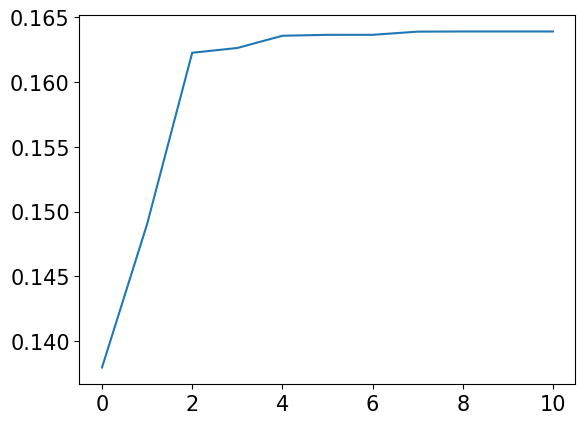

In [ ]:
# restore threshold's history
th_history = []
dir_path = nts_dir
# dir_path 以下にあるファイル一覧を pathlib を使って取得
path = pathlib.Path(dir_path)
file_list = list(path.glob("*"))
# タイトルを日付順にソートし、for 文で処理
file_list.sort()
all_target = []
features = []
for file in file_list:
    # 各csvファイルを読み込み、1列目をaction_id, 2~最終行までをfeature_1~feature_N, 最終行をtargetとして読み込む
    df = pd.read_csv(file, header=None)
    action_id = df[0]
    feature = df.iloc[:, 1:-1]
    features.append(feature)
    target = df.iloc[:, -1]
    all_target.extend([e for e in target if pd.notnull(e)])
    th = np.percentile(np.array(all_target), 90)
    # print(th, all_target)
    print(th)
    th_history.append(max(th, max(th_history, default=0)))
print(th_history)
# target_list = np.array(target_list)
# ax.plot(list(range(len(target_list[1:]))), target_list[1:], label=dir_path.strip("/"), color=method2color[methods[i]], marker=mathods2marker[methods[i]], linestyle=method2style[methods[i]])
# features_list.append(features)
plt.plot(th_history)

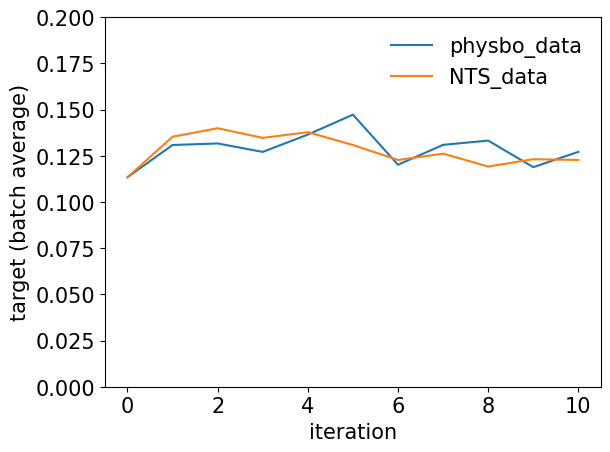

In [ ]:
import pathlib

fig, ax = plt.subplots()
features_list = []
target_list_all = []
for dir_path in [physbo_dir, nts_dir]:
    # dir_path 以下にあるファイル一覧を pathlib を使って取得
    path = pathlib.Path(dir_path)
    file_list = list(path.glob("*"))
    # タイトルを日付順にソートし、for 文で処理
    file_list.sort()
    target_list = []
    features = []
    for file in file_list:
        # 各csvファイルを読み込み、1列目をaction_id, 2~最終行までをfeature_1~feature_N, 最終行をtargetとして読み込む
        df = pd.read_csv(file, header=None)
        action_id = df[0]
        feature = df.iloc[:, 1:-1]
        features.append(feature)
        target = df.iloc[:, -1]
        target_list.append(target)
    target_list = np.array(target_list)
    ax.plot(list(range(len(target_list))), np.nanmean(target_list, axis=1), label=dir_path.strip("/"))
    features_list.append(features)
    target_list_all.append(np.nanmax(target_list, axis=1))
ax.legend(frameon=False, fontsize=15)
ax.set_ylabel("target (batch average)", fontsize=15)
ax.set_xlabel("iteration", fontsize=15)
ax.set_ylim(0, 0.2)
plt.show()

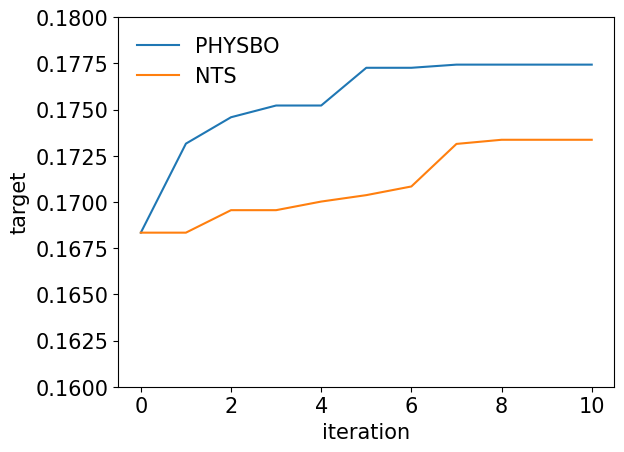

In [ ]:
target_list_all = np.array(target_list_all)
physbo_target, nts_target = [np.max(target_list_all[0][0])], [np.max(target_list_all[1][0])]
for i in range(1, len(target_list_all[0])):
    physbo_target.append(np.max([np.max(physbo_target), target_list_all[0][i]]))
    nts_target.append(np.max([np.max(nts_target), target_list_all[1][i]]))
physbo_target, nts_target = np.array(physbo_target), np.array(nts_target)
plt.plot(list(range(len(physbo_target))), physbo_target, label="PHYSBO")
plt.plot(list(range(len(nts_target))), nts_target, label="NTS")
plt.legend(frameon=False, fontsize=15)
plt.ylabel("target", fontsize=15)
plt.xlabel("iteration", fontsize=15)
plt.ylim(0.16, 0.18)
plt.show()

In [ ]:
from sklearn.metrics.pairwise import pairwise_distances
import networkx as nx

def maximal_independent_set(D, t):
    adj_matrix = np.array(D <= t, dtype=int)
    np.fill_diagonal(adj_matrix, 0)
    G = nx.from_numpy_array(np.array(adj_matrix))
    return nx.maximal_independent_set(G)

In [ ]:
all_target, all_features = defaultdict(list), defaultdict(list)
for i, dir_path in enumerate([physbo_dir, nts_dir]):
    # dir_path 以下にあるファイル一覧を pathlib を使って取得
    path = pathlib.Path(dir_path)
    file_list = list(path.glob("*"))
    # タイトルを日付順にソートし、for 文で処理
    file_list.sort()
    for file in file_list:
        # 各csvファイルを読み込み、1列目をaction_id, 2~最終行までをfeature_1~feature_N, 最終行をtargetとして読み込む
        df = pd.read_csv(file, header=None)
        action_id = df[0]
        feature = df.iloc[:, 1:-1].to_numpy()
        target = df.iloc[:, -1].to_numpy()
        if len(all_target[i]) == 0 and len(all_features[i]) == 0:
            all_target[i].append(target)
            all_features[i].append(feature)
        else:
            # print(all_target[i][-1])
            all_target[i].append(np.concatenate((all_target[i][-1], target)))
            all_features[i].append(np.concatenate((all_features[i][-1], feature)))

In [ ]:
th = 0.14
t = 10
circles_above_th_dict = defaultdict(list)
for i in range(2):
    for feature, target in zip(all_features[i], all_target[i]):
        feature_above_th = np.array(feature)[np.array(target) > th]
        print(i, len(feature_above_th))
        D = pairwise_distances(feature_above_th, metric="euclidean")
        for _ in range(200):
            v = np.max([len(set(maximal_independent_set(D, t))) for _ in range(20)])
            # circles_above_th_dict[i].append(len(set(s)))
            if len(circles_above_th_dict[i]) == 0:
                circles_above_th_dict[i].append(v)
            elif circles_above_th_dict[i][-1] <= v:
                circles_above_th_dict[i].append(v)
                break

circles_above_th_dict

0 5
0 29
0 49
0 64
0 89
0 122
0 130
0 153
0 177
0 191
0 215
1 5
1 17
1 34
1 57
1 79
1 102
1 110
1 131
1 159
1 178
1 197


defaultdict(list,
            {0: [np.int64(4),
              np.int64(4),
              np.int64(5),
              np.int64(7),
              np.int64(8),
              np.int64(17),
              np.int64(17),
              np.int64(17),
              np.int64(28),
              np.int64(36),
              np.int64(40),
              np.int64(49)],
             1: [np.int64(4),
              np.int64(4),
              np.int64(13),
              np.int64(22),
              np.int64(30),
              np.int64(34),
              np.int64(37),
              np.int64(39),
              np.int64(43),
              np.int64(53),
              np.int64(60),
              np.int64(62)]})

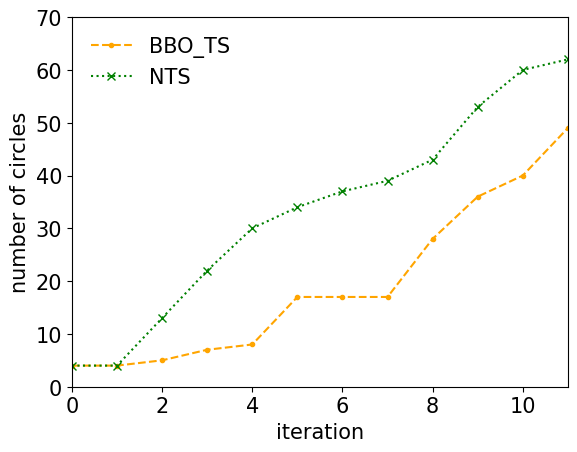

In [ ]:
fig, ax = plt.subplots()
methods = ["BBO_TS", "NTS"]
for i, method in enumerate(methods):
    # plt.plot(circles, label=methods[i], color=method2color[methods[i]])
    ax.plot(list(range(12)), circles_above_th_dict[i], label=method, color=method2color[methods[i]], marker=mathods2marker[methods[i]], linestyle=method2style[methods[i]])
ax.legend(frameon=False, fontsize=15)
ax.set_ylabel("number of circles", fontsize=15)
ax.set_xlabel("iteration", fontsize=15)
ax.set_xlim(0, 11)
ax.set_ylim(0, 70)
plt.savefig("circles_by_iteration.pdf", bbox_inches='tight')

In [ ]:
all_target, all_features = defaultdict(list), defaultdict(list)
for i, dir_path in enumerate([physbo_dir, nts_dir]):
    # dir_path 以下にあるファイル一覧を pathlib を使って取得
    path = pathlib.Path(dir_path)
    file_list = list(path.glob("*"))
    # タイトルを日付順にソートし、for 文で処理
    file_list.sort()
    target_list = []
    features = []
    for file in file_list:
        # 各csvファイルを読み込み、1列目をaction_id, 2~最終行までをfeature_1~feature_N, 最終行をtargetとして読み込む
        df = pd.read_csv(file, header=None)
        action_id = df[0]
        feature = df.iloc[:, 1:-1].to_numpy()
        target = df.iloc[:, -1].to_numpy()
        for j in range(len(feature)):
            all_target[i].append(target[j])
            all_features[i].append(feature[j])
len(all_target[0]), len(all_target[1]), len(all_features[0]), len(all_features[1])

(528, 528, 528, 528)

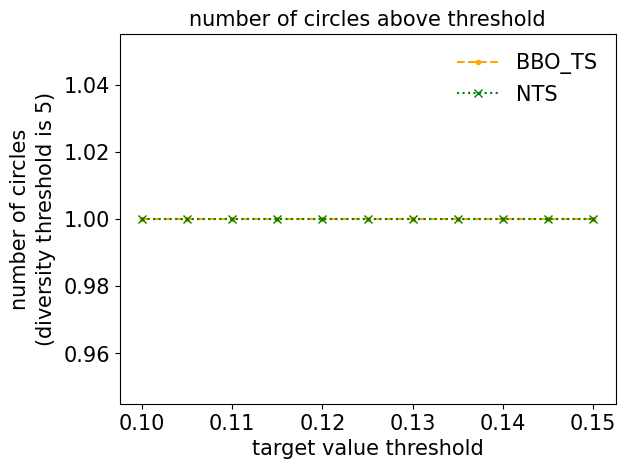

In [ ]:
circles_above_th_dict = defaultdict(list)
fig, ax = plt.subplots()
th_list = np.arange(0.1, 0.151, 0.005)
t = 5
for th in th_list:
    for i in range(2):
        feature_above_th = np.array(all_features[i])[np.array(all_target[i]) > th]
        D = pairwise_distances(feature_above_th, metric="hamming")
        s = maximal_independent_set(D, t)
        circles_above_th_dict[i].append(len(set(s)))
for i in range(2):
    ax.plot(th_list, circles_above_th_dict[i], label=methods[i], color=method2color[methods[i]], marker=mathods2marker[methods[i]], linestyle=method2style[methods[i]])
    # ax.plot(th_list, circles_above_th_dict[i], marker=mathods2marker[methods[i]])
# ax.set_xticks(th_list)
ax.set_title("number of circles above threshold", fontsize=15)
ax.set_xlabel("target value threshold", fontsize=15)
ax.set_ylabel("number of circles" + '\n' + rf"(diversity threshold is ${t}$)", fontsize=15)
ax.legend(frameon=False, fontsize=15)
plt.savefig("circles_by_threshold.pdf", bbox_inches='tight')

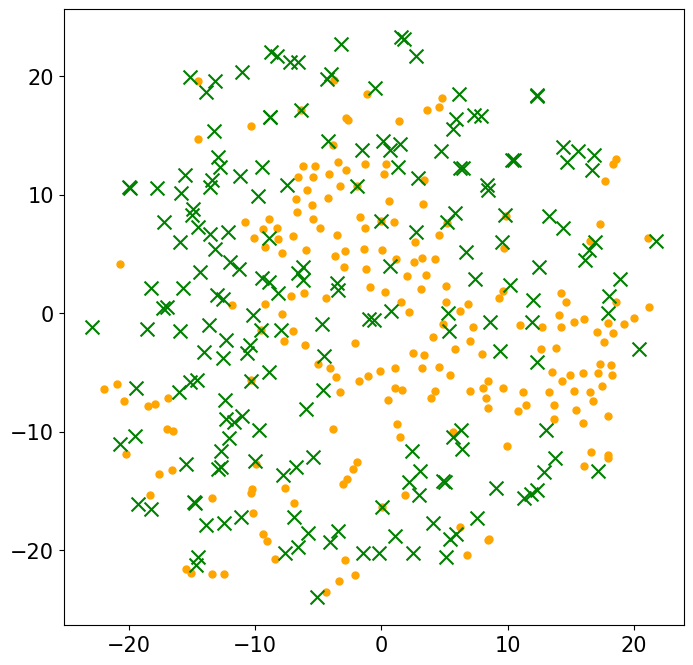

In [ ]:
# 閾値を超えたサンプルがそれぞれどのように分布しているか、tSNEで2次元に可視化する
import mplcursors
from sklearn.manifold import TSNE
fig, ax = plt.subplots(figsize=(8, 8))
th = 0.14
tsne = TSNE(n_components=2, random_state=0)
feature_above_th = list(np.array(all_features[0])[np.array(all_target[0]) > th])
N = len(feature_above_th)
feature_above_th += list(np.array(all_features[1])[np.array(all_target[1]) > th])
feature_above_th = np.array(feature_above_th)
X_embedded = tsne.fit_transform(feature_above_th)
for i in range(2):
    if i == 0:
        ax.scatter(X_embedded[:N, 0], X_embedded[:N, 1], label="physbo", marker='.', color=method2color[methods[i]], s=100)
    else:
        sc = ax.scatter(X_embedded[N:, 0], X_embedded[N:, 1], label="NTS", marker='x', color=method2color[methods[i]], s=100)
    # tSNE1 が10以上、tSNE2が10以上のエリアを黒のラインで区切る
    # tSNE1 については、tSNE2が10の点より上のみに線を引く
    # tSNE2 については、tSNE1が10の点より右のみに線を引く

# cursor = mplcursors.cursor(sc, hover=True)
# @cursor.connect("add")
# def _(sel):
#     sel.annotation.set_text(str(sel.index))  # sel.index がデータ点のインデックス
# plt.show()
# ax.axvline(x=10, ymin=10, color='red', linestyle='--')
# ax.hlines(y=8, xmin=10, xmax=23, color='black', linestyle='--')
# ax.vlines(x=10, ymin=8, ymax=23, color='black', linestyle='--')
# ax.hlines(y=-3, xmin=13, xmax=23, color='black', linestyle='--')
# ax.vlines(x=13, ymax=-3, ymin=-23, color='black', linestyle='--')
# ax.hlines(y=8, xmin=-15, xmax=-10, color='black', linestyle='--')
# ax.hlines(y=-1, xmin=-23, xmax=-15, color='black', linestyle='--')
# ax.vlines(x=-10, ymax=8, ymin=23, color='black', linestyle='--')
# ax.vlines(x=-15, ymin=-1, ymax=8, color='black', linestyle='--')
# legend はfigureの外に表示
# ax.legend(frameon=False, fontsize=15, bbox_to_anchor=(1., 1), loc='upper left')
# ax.set_xlabel("tSNE1", fontsize=15)
# ax.set_ylabel("tSNE2", fontsize=15)
# ax.set_xlim(-23, 23)
# ax.set_ylim(-23, 23)
# tight_layout でfigureのレイアウトを調整
# plt.tight_layout()
plt.savefig(f"tsne_plot_{th}.pdf")

th=0.14
BBO TS, 3225.0
NTS, 2955.0


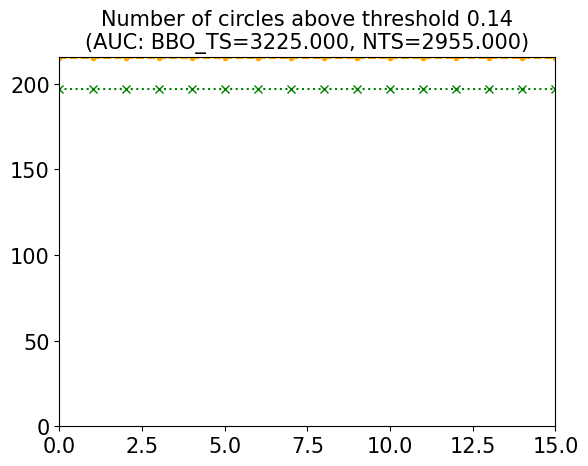

In [ ]:
# th=0.14 で固定した時のCirclesと閾値の関係
# fig, ax = plt.subplots()
dist_threshold_list = np.arange(0, 16, 1)
N = 48 * 10
circles_auc_dict = defaultdict(list)
for th in [0.14]:
    all_target, all_features = defaultdict(list), defaultdict(list)
    circles_above_th_dict = defaultdict(list)
    for i, dir_path in enumerate([physbo_dir, nts_dir]):
        # dir_path 以下にあるファイル一覧を pathlib を使って取得
        path = pathlib.Path(dir_path)
        file_list = list(path.glob("*"))
        # タイトルを日付順にソートし、for 文で処理
        file_list.sort()
        target_list = []
        features = []
        for file in file_list:
            # 各csvファイルを読み込み、1列目をaction_id, 2~最終行までをfeature_1~feature_N, 最終行をtargetとして読み込む
            df = pd.read_csv(file, header=None)
            action_id = df[0]
            feature = df.iloc[:, 1:-1].to_numpy()
            # 0 より大きい値は全て 1 に変換
            feature[feature > 0] = 1
            target = df.iloc[:, -1].to_numpy()
            for j in range(len(feature)):
                all_target[i].append(target[j])
                all_features[i].append(feature[j])
    for t in dist_threshold_list:
        for i in range(2):
            # print(i, t)
            for _ in range(100):
                feature_above_th = np.array(all_features[i])[np.array(all_target[i]) > th]
                N = len(feature_above_th)
                D = pairwise_distances(feature_above_th, metric="euclidean") * 48
                s = maximal_independent_set(D, t)
                v = len(set(s))
                # print(v)
                if len(circles_above_th_dict[i]) > 0:
                    if v <= circles_above_th_dict[i][-1]:
                        circles_above_th_dict[i].append(v)
                        break
                    else:
                        print(f"{i}, {t}, {v}, {circles_above_th_dict[i][-1]}")
                else:
                    circles_above_th_dict[i].append(v)
                    break
    print(f"th={th}")
    bbo_ts_auc = np.trapezoid(np.array(circles_above_th_dict[0]), dist_threshold_list)
    nts_auc = np.trapezoid(np.array(circles_above_th_dict[1]), dist_threshold_list)
    circles_auc_dict[0].append(bbo_ts_auc)
    circles_auc_dict[1].append(nts_auc)
    print(f"BBO TS, {bbo_ts_auc}")
    print(f"NTS, {nts_auc}")
    fig, ax = plt.subplots()
    ax.plot(dist_threshold_list, circles_above_th_dict[0], label="BBO_TS", color=method2color["BBO_TS"], marker=mathods2marker["BBO_TS"], linestyle=method2style["BBO_TS"])
    ax.plot(dist_threshold_list, circles_above_th_dict[1], label="NTS", color=method2color["NTS"], marker=mathods2marker["NTS"], linestyle=method2style["NTS"])
    ax.set_title(rf"Number of circles above threshold {th}" + '\n' + rf"(AUC: BBO_TS={bbo_ts_auc:.3f}, NTS={nts_auc:.3f})", fontsize=15)
    ax.set_xlim(min(dist_threshold_list), max(dist_threshold_list))
    ax.set_ylim(0)
    # plt.savefig(f"circles_{th}.pdf", bbox_inches='tight')

In [ ]:
circles_above_th_dict[0], len(dist_threshold_list)

([215, 215, 215, 117, 110, 107, 45, 43, 43, 12, 12, 12, 4, 4, 3, 1], 16)

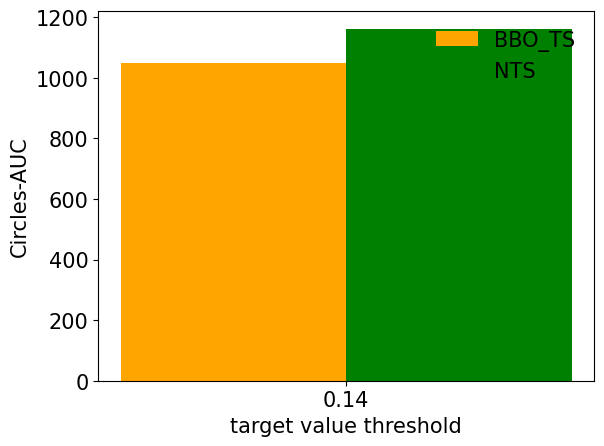

In [ ]:
fig, ax = plt.subplots()
# circles_auc_dict を棒グラフで可視化
# 0.13, 0.14, 0.15 の3つの閾値に対して、BBO_TS と NTS の2つの手法を比較
th_list = [0.14]
x = np.arange(len(th_list))  # the label locations
width = 0.35  # the width of the bars
rects1 = ax.bar(x - width/2, circles_auc_dict[0], width, label='BBO_TS', color=method2color["BBO_TS"])
rects2 = ax.bar(x + width/2, circles_auc_dict[1], width, label='NTS', color=method2color["NTS"])
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Circles-AUC', fontsize=15)
ax.set_xlabel('target value threshold', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(th_list)
ax.legend(frameon=False, fontsize=15)
plt.savefig("circles_auc.pdf", bbox_inches='tight')

In [ ]:
circles_auc_dict

defaultdict(list, {0: [1050.0], 1: [1162.0]})

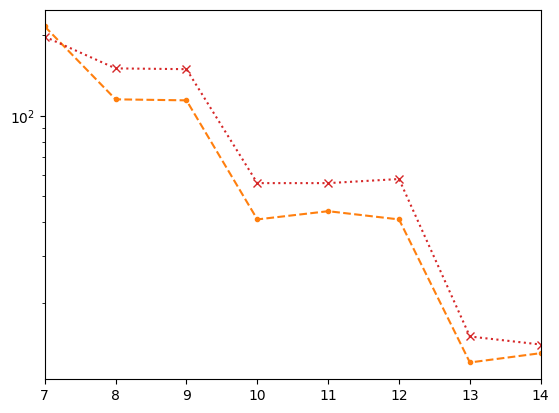

In [ ]:
fig, ax = plt.subplots()
ax.plot(dist_threshold_list, circles_above_th_dict[0], label="BBO_TS", color=method2color["BBO_TS"], marker=mathods2marker["BBO_TS"], linestyle=method2style["BBO_TS"])
ax.plot(dist_threshold_list, circles_above_th_dict[1], label="NTS", color=method2color["NTS"], marker=mathods2marker["NTS"], linestyle=method2style["NTS"])
ax.set_xlim(min(dist_threshold_list), max(dist_threshold_list))
# ax.set_ylim(0, 225)
ax.set_yscale('log')
plt.savefig("circles_log.pdf", bbox_inches='tight')

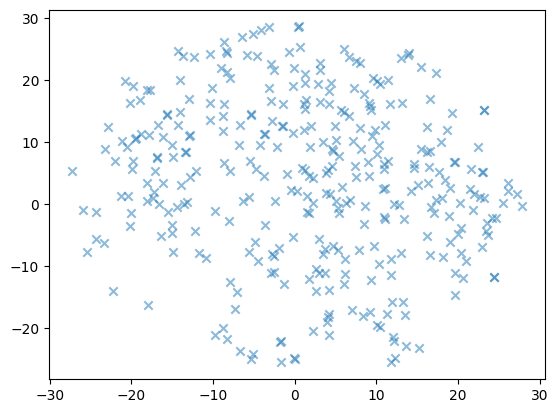

In [ ]:
import mplcursors
fig, ax = plt.subplots()
X_embedded_tmp = X_embedded[N:, :]
sc = ax.scatter(X_embedded_tmp[:, 0], X_embedded_tmp[:, 1], marker='x', alpha=0.5)

# hover 時に index をツールチップで表示hover=True)
cursor = mplcursors.cursor(sc, hover=True)
@cursor.connect("add")
def _(sel):
    sel.annotation.set_text(str(sel.index))  # sel.index がデータ点のインデックス
plt.show()



# from adjustText import adjust_text
# import matplotlib.pyplot as plt
# import numpy as np

# np.random.seed(0)
# x, y = np.random.rand(20), np.random.rand(20)

# texts = [ax.text(dat[0], dat[1], str(i), fontsize=10) for i, dat in enumerate(X_embedded_tmp)]
# adjust_text(texts, ax=ax, expand_text=(2, 2), force_explode=(5, 5),
#             arrowprops=dict(arrowstyle='--', lw=1))   # ← 矢印で視認性も UP
# # ax.scatter(X_embedded[:, 0], X_embedded[:, 1], s=10, c='black', alpha=0.5)
# # texts = [ax.text(dat[0], dat[1], str(i), fontsize=10) for i, dat in enumerate(X_embedded_2)]
# # adjust_text(texts, ax=ax, expand_text=(2, 2),
# #             arrowprops=dict(arrowstyle='-', lw=1))   # ← 矢印で視認性も UP
# # # ax.scatter(X_embedded[:, 0], X_embedded[:, 1], s=10, c='black', alpha=0.5)
# # texts = [ax.text(dat[0], dat[1], str(i), fontsize=10) for i, dat in enumerate(X_embedded_3)]
# # # ax.scatter(X_embedded_4[:, 0], X_embedded_4[:, 1], s=10, c='black', alpha=0.5)
# # adjust_text(texts, ax=ax, expand_text=(2, 2),
# #             arrowprops=dict(arrowstyle='-', lw=1))   # ← 矢印で視認性も UP
# # texts = [ax.text(dat[0], dat[1], str(i), fontsize=10) for i, dat in enumerate(X_embedded_4)]
# # adjust_text(texts, ax=ax, expand_text=(2, 2),
# #             arrowprops=dict(arrowstyle='-', lw=1))   # ← 矢印で視認性も UP


# # plt.xlim(-23, 23)
# # plt.ylim(-23, 23)
# # plt.show()
# print(texts)
# plt.savefig("annot.pdf")


In [ ]:
X_embedded_tmp[0]

array([ 15.232896, -23.155909], dtype=float32)

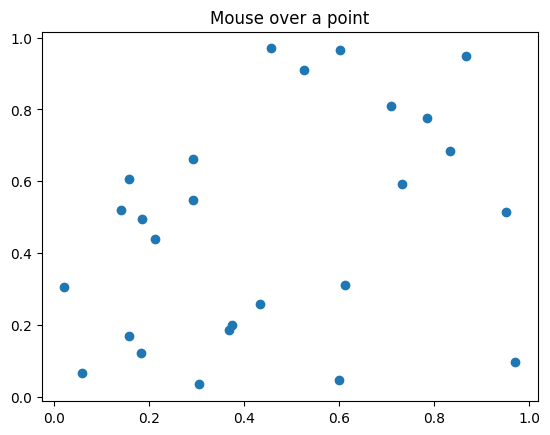

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import mplcursors
np.random.seed(42)

fig, ax = plt.subplots()
ax.scatter(*np.random.random((2, 26)))
ax.set_title("Mouse over a point")

mplcursors.cursor(hover=True)

plt.show()

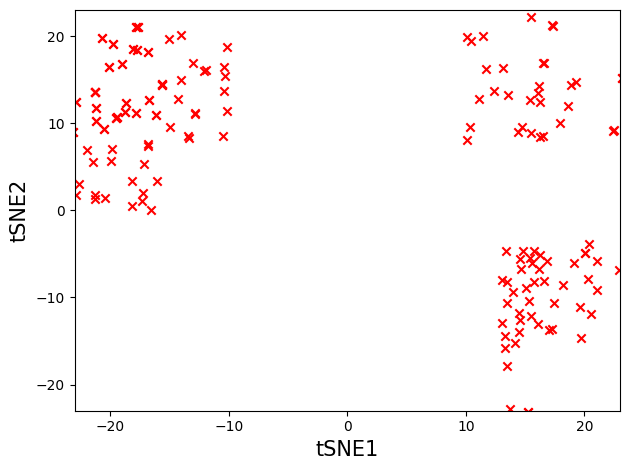

In [ ]:
from adjustText import adjust_text
fig, ax = plt.subplots()
i = 1
index = np.array(all_target[i]) > 0.13
feature_above_th = np.array(all_features[i])[index]
target_above_th = np.array(all_target[i])[index]
# tsne = TSNE(n_components=2, random_state=0)
# X_embedded = tsne.fit_transform(feature_above_th)
# X_embedded のうち、一つ目の要素が10以上、2つ目の要素が10以上のものを検出
X_embedded = np.array(X_embedded)
X_embedded_1 = X_embedded[(X_embedded[:, 0] > 10) & (X_embedded[:, 1] > 8)]
# texts = [plt.text(dat[0], dat[1], str(i), fontsize=9) for i, dat in enumerate(X_embedded_1)]
# # print(texts)
# # 衝突回避アルゴリズムを適用
# adjust_text(texts,
#     ax=ax,
#     expand_text=(1.05, 1.2),     # テキスト同士・点との最小距離係数
#     arrowprops=dict(arrowstyle='-'))  # 必要なら矢印
# for i, (xi, yi) in enumerate(X_embedded_1):
#     if i == 12 or i == 8:
#         ax.annotate(i, (xi, yi),
#                     textcoords="offset points",
#                     xytext=(-15, -4),
#                     ha='left', va='bottom', fontsize=10)
#     else:
#         ax.annotate(i, (xi, yi),
#                     textcoords="offset points",
#                     xytext=(3, -4),
#                     ha='left', va='bottom', fontsize=10)

ax.scatter(X_embedded_1[:, 0], X_embedded_1[:, 1], label="NTS", marker='x', color='red')
# X_embedded_1 におけるindexを点の横に追加
# X_embedded のうち、一つ目の要素が13以上、2つ目の要素が-3以下のものを検出
X_embedded_2 = X_embedded[(X_embedded[:, 0] > 13) & (X_embedded[:, 1] < -3)]
ax.scatter(X_embedded_2[:, 0], X_embedded_2[:, 1], label="NTS", marker='x', color='red')
# for i, (xi, yi) in enumerate(X_embedded_2):
#     if i == 9 or i == 7:
#         ax.annotate(i, (xi, yi),
#                     textcoords="offset points",
#                     xytext=(-15, -4),
#                     ha='left', va='bottom', fontsize=10)
#     else:
#         ax.annotate(i, (xi, yi),
#                     textcoords="offset points",
#                     xytext=(3, -4),
#                     ha='left', va='bottom', fontsize=10)
# X_embedded のうち、一つ目の要素が-15以下、2つ目の要素が-1以上のものを検出
X_embedded_3 = X_embedded[(X_embedded[:, 0] < -15) & (X_embedded[:, 1] > -1)]
ax.scatter(X_embedded_3[:, 0], X_embedded_3[:, 1], label="NTS", marker='x', color='red')
c = 0
# for i, (xi, yi) in enumerate(X_embedded_3):
#     ax.annotate(i, (xi, yi),
#                 textcoords="offset points",
#                 xytext=(3, -4),
#                 ha='left', va='bottom', fontsize=10)
#     c += 1
# X_embedded のうち、一つ目の要素が-10以下、2つ目の要素が8以上のものを検出
X_embedded_4 = X_embedded[(X_embedded[:, 0] < -10) & (X_embedded[:, 1] > 8)]
ax.scatter(X_embedded_4[:, 0], X_embedded_4[:, 1], label="NTS", marker='x', color='red')
# for i, (xi, yi) in enumerate(X_embedded_4):
#     ax.annotate(i+c, (xi, yi),
#                 textcoords="offset points",
#                 xytext=(4*(-1)**i, 2*(-1)**(i+1)),
#                 ha='left', va='bottom', fontsize=10)
# legend はfigureの外に表示
# ax.legend(frameon=False, fontsize=15, loc='upper left')
ax.set_xlabel("tSNE1", fontsize=15)
ax.set_ylabel("tSNE2", fontsize=15)
ax.set_xlim(-23, 23)
ax.set_ylim(-23, 23)
# # tight_layout でfigureのレイアウトを調整
plt.tight_layout()
plt.savefig(f"tsne_plot_{th}_nts_specific.pdf")

In [ ]:
X_embedded_tmp = X_embedded[N:, :]
target_arr = np.array(all_target[1])
feature_tmp = np.array(all_features[1])[target_arr > th]
target_tmp = target_arr[target_arr > th]
assert len(target_tmp) == len(feature_tmp), "target_arr and feature_tmp must have the same length"
# feature_tmp の各列をそれぞれfeature_1, feature_2, ..., feature_Nとし、target_tmpをtargetとしてcsvファイルに出力
feature_df = pd.DataFrame(feature_tmp)
feature_df.columns = [f"feature_{i+1}" for i in range(feature_tmp.shape[1])]
feature_df["target"] = target_tmp
# 0から始まる id 列を追加
feature_df.insert(0, "id", range(len(feature_df)))
feature_df["id"] = feature_df["id"].astype(int)
feature_df.to_csv("NTS_features_above_threshold.csv", index=False, header=True)

# feature_tmp = feature_above_th[(X_embedded[:, 0] < -10) & (X_embedded[:, 1] > 8)]
# target_tmp = target_above_th[(X_embedded[:, 0] < -10) & (X_embedded[:, 1] > 8)]
# feature_df = pd.DataFrame(feature_tmp)
# feature_df.columns = [f"feature_{i+1}" for i in range(feature_tmp.shape[1])]
# feature_df["target"] = target_tmp
# feature_df.to_csv("NTS_features_above_threshold_-10_8.csv", index=False, header=True)

# feature_tmp = feature_above_th[(X_embedded[:, 0] < -15) & (X_embedded[:, 1] > -1)]
# target_tmp = target_above_th[(X_embedded[:, 0] < -15) & (X_embedded[:, 1] > -1)]
# feature_df = pd.DataFrame(feature_tmp)
# feature_df.columns = [f"feature_{i+1}" for i in range(feature_tmp.shape[1])]
# feature_df["target"] = target_tmp
# feature_df.to_csv("NTS_features_above_threshold_-15_-1.csv", index=False, header=True)

# feature_tmp = feature_above_th[(X_embedded[:, 0] > 13) & (X_embedded[:, 1] < -3)]
# target_tmp = target_above_th[(X_embedded[:, 0] > 13) & (X_embedded[:, 1] < -3)]
# feature_df = pd.DataFrame(feature_tmp)
# feature_df.columns = [f"feature_{i+1}" for i in range(feature_tmp.shape[1])]
# feature_df["target"] = target_tmp
# feature_df.to_csv("NTS_features_above_threshold_13_-3.csv", index=False, header=True)

# # feature_above_th[(X_embedded[:, 0] < -15) & (X_embedded[:, 1] > -1)]
# # feature_above_th[(X_embedded[:, 0] > 13) & (X_embedded[:, 1] < -3)]


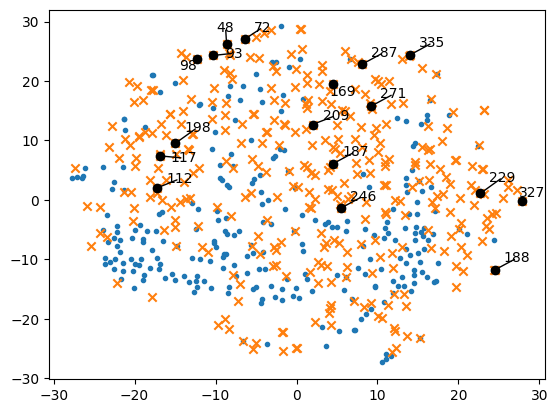

In [ ]:
target_index = [
    187
    ,198
    ,112
    ,229
    ,287
    ,327
    ,335
    ,48
    ,93
    ,98
    ,117
    ,271
    ,72
    ,209
    ,188
    ,169
    ,246
]

from adjustText import adjust_text

fig, ax = plt.subplots()
for i in range(2):
    if i == 0:
        ax.scatter(X_embedded[:N, 0], X_embedded[:N, 1], label="physbo", marker='.')
    else:
        ax.scatter(X_embedded[N:, 0], X_embedded[N:, 1], label="NTS", marker='x')
ax.plot(X_embedded_tmp[target_index, 0], X_embedded_tmp[target_index, 1], marker='o', linestyle='None', color='black')
texts = [ax.text(X_embedded_tmp[j][0], X_embedded_tmp[j][1], str(j), fontsize=10) for i, j in enumerate(target_index)]
adjust_text(texts, ax=ax, expand_text=(2, 2), force_explode=(2, 2),
            arrowprops=dict(arrowstyle='-', lw=1))   # ← 矢印で視認性も UP
plt.savefig("nts_physbo_target_index.pdf", bbox_inches='tight')

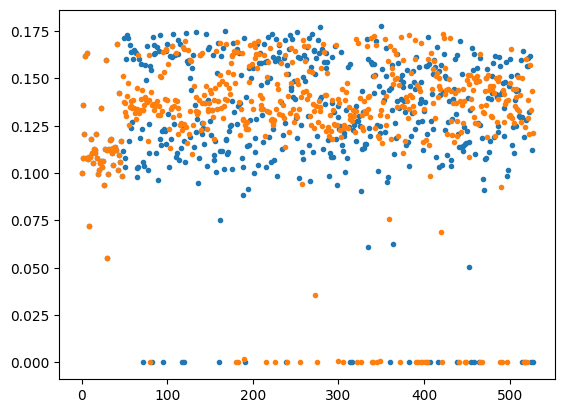

In [ ]:
# all_target の各配列について、バイオリンプロットで値の分布を可視化
fig, ax = plt.subplots()
for i in range(2):
    plt.plot(all_target[i], '.')